In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops, find_contours
from scipy.ndimage import gaussian_filter
import rasterio
from rasterio.mask import mask
from rasterio.warp import transform_bounds
from shapely.geometry import box
import geopandas as gpd
from matplotlib.patches import Circle
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import colormaps

In [2]:
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'

In [3]:
# NDVI calc
def calculate_ndvi(nir, red):
    """Calculate the NDVI using NIR and Red bands."""
    np.seterr(divide="ignore", invalid="ignore")
    ndvi = (nir - red) / (nir + red)
    return np.clip(ndvi, -1, 1)  

In [4]:
# Clip Sentinel-2 band to bounding box
def load_band_from_s3(band_path, bbox, downsample_factor=1):
    try:
        with rasterio.open(band_path) as src:
            bbox_transformed = transform_bounds("EPSG:4326", src.crs, *bbox)
            bbox_geom = [box(*bbox_transformed)]
            out_image, out_transform = mask(src, bbox_geom, crop=True)
            out_image = out_image[0]  # Extract the first band
            if downsample_factor > 1:
                out_image = out_image[::downsample_factor, ::downsample_factor]
            return out_image, out_transform, src.crs
    except Exception as e:
        print(f"Error loading or clipping file: {band_path} - {e}")
        return None, None, None

In [5]:
# Detect fields using NDVI and connected components
def process_ndvi_and_detect_fields(red_band, nir_band, ndvi_threshold=0.3, min_area_pixels=100, max_area_pixels=500000):
    
    ndvi = calculate_ndvi(nir_band, red_band)
    print(f"NDVI calculated. NDVI range: {np.nanmin(ndvi)} to {np.nanmax(ndvi)}")

    
    ndvi_smoothed = gaussian_filter(ndvi, sigma=1)
    crop_mask = ndvi_smoothed > ndvi_threshold
    print(f"NDVI threshold applied: {ndvi_threshold}")

    # Label connected components
    labeled_fields, num_fields = label(crop_mask, connectivity=2, return_num=True)
    print(f"Number of labeled components: {num_fields}")

    # Filter fields based on area
    field_properties = [
        prop for prop in regionprops(labeled_fields)
        if min_area_pixels <= prop.area <= max_area_pixels
    ]
    print(f"Number of fields detected after filtering: {len(field_properties)}")

    return ndvi_smoothed, labeled_fields, field_properties

In [6]:
def evaluate_field_metrics(field_properties):
    field_areas = []
    shape_complexities = []
    avg_contour_lengths = []

    for field in field_properties:
        # Calculate area in acres
        field_area_m2 = field.area * (10 ** 2)  # 10m resolution
        field_area_acres = field_area_m2 / 4046.86
        field_areas.append(field_area_acres)

        # Shape complexity (Perimeter^2 / Area)
        shape_complexity = (field.perimeter ** 2) / field.area
        shape_complexities.append(shape_complexity)

        # Average contour length
        contours = find_contours(field.image, level=0.5)
        avg_contour_length = np.mean([len(contour) for contour in contours]) if contours else 0
        avg_contour_lengths.append(avg_contour_length)

    
    print(f"Number of Fields: {len(field_properties)}")
    print(f"Average Field Size: {np.mean(field_areas):.2f} acres")
    print(f"Average Shape Complexity: {np.mean(shape_complexities):.2f}")
    print(f"Average Contour Length: {np.mean(avg_contour_lengths):.2f}")

NDVI calculated. NDVI range: 0.0 to 1.0
NDVI threshold applied: 0.3
Number of labeled components: 546
Number of fields detected after filtering: 14
Number of Fields: 14
Average Field Size: 9.42 acres
Average Shape Complexity: 25.47
Average Contour Length: 16.85


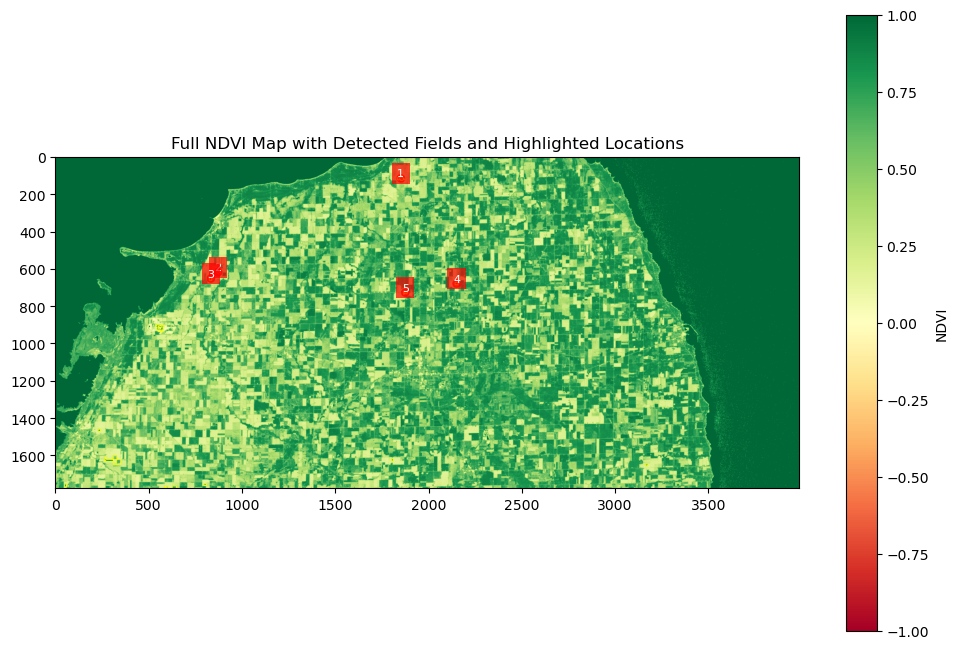

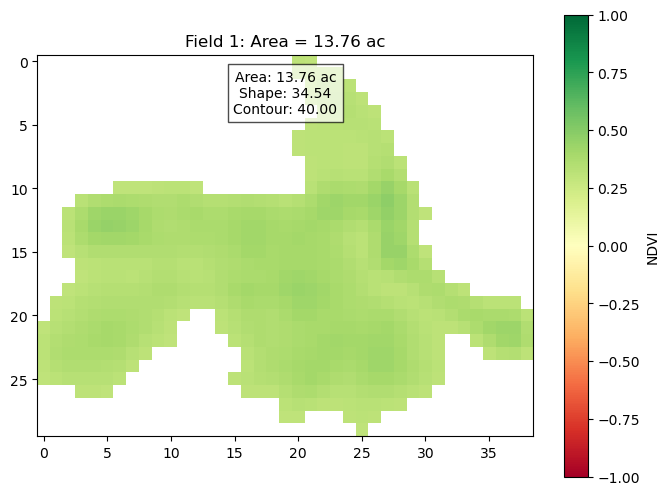

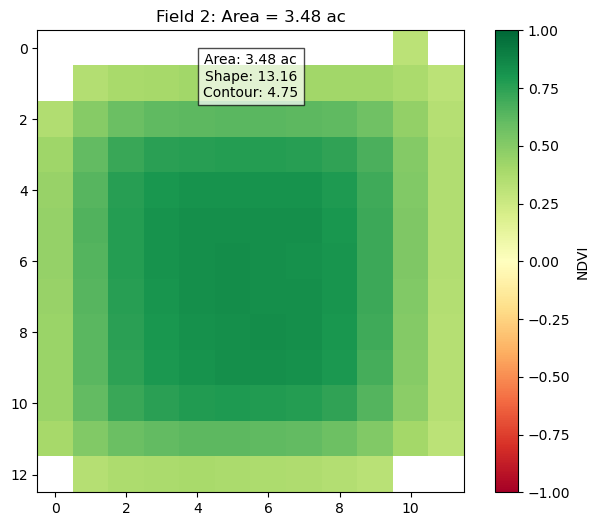

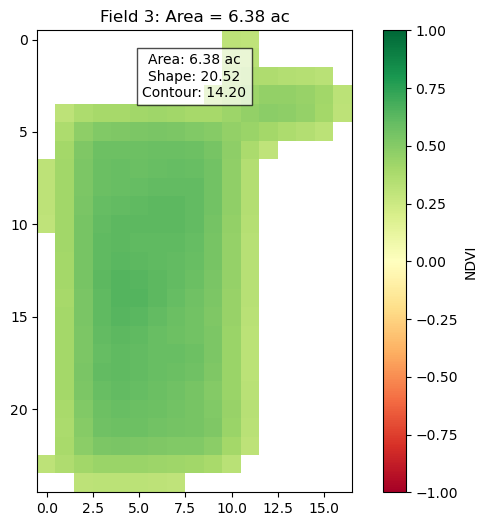

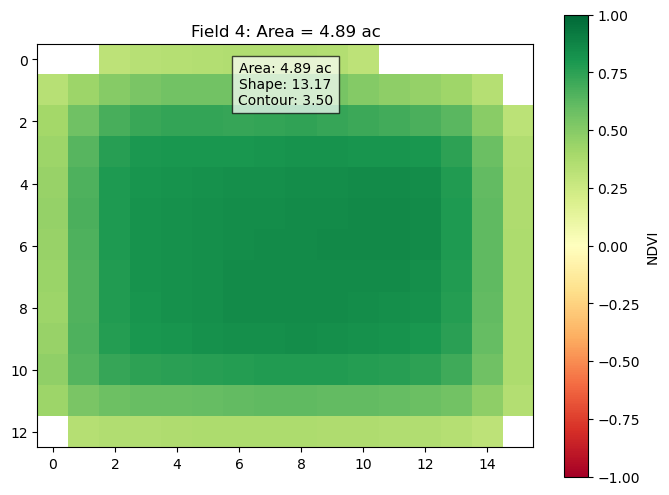

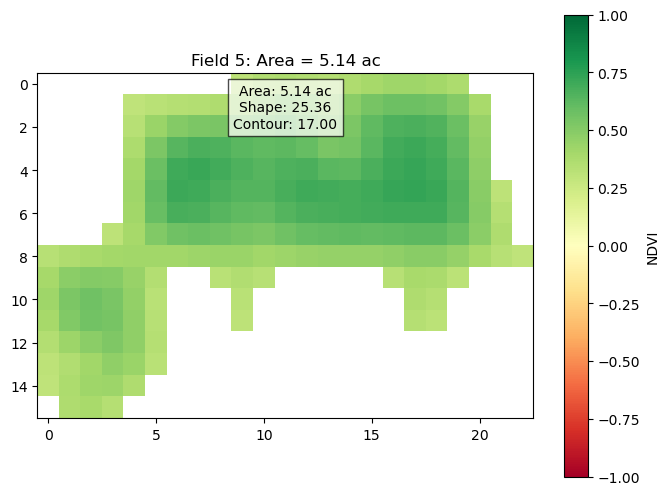

In [7]:
def visualize_ndvi_and_fields(ndvi, labeled_fields, field_properties, num_fields_to_visualize=5):
    """Visualize NDVI with field contours, individual fields, total acreage, and field annotations."""
    # Check if NDVI has a range
    if np.nanmin(ndvi) == np.nanmax(ndvi):
        print("NDVI has no range; skipping full NDVI visualization.")
        return

    # Calculate total acreage for all detected fields
    total_area_m2 = sum([field.area * (10 ** 2) for field in field_properties])  # Assuming 10m resolution
    total_area_acres = total_area_m2 / 4046.86

    # Full NDVI map with field contours and field markers
    plt.figure(figsize=(12, 8))
    ndvi_plot = plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.colorbar(ndvi_plot, label="NDVI")
    for field in field_properties:
        field_mask = labeled_fields == field.label
        plt.contour(field_mask, colors="yellow", linewidths=0.5)

    # Add red markers and field numbers to highlight field centroids
    for i, field in enumerate(field_properties[:num_fields_to_visualize]):
        centroid = field.centroid
        plt.gca().add_patch(
            Circle((centroid[1], centroid[0]), 20, color='red', fill=True, alpha=0.6)
        )
        plt.text(
            centroid[1], centroid[0] - 10, f"{i + 1}",  # Add numbers (1, 2, ...) above markers
            color="white", fontsize=8, ha="center", bbox=dict(facecolor="red", alpha=0.7, edgecolor='none')
        )

    plt.title("Full NDVI Map with Detected Fields and Highlighted Locations")
    plt.show()

    # Individual field visualizations
    for i, field in enumerate(field_properties[:num_fields_to_visualize]):
        minr, minc, maxr, maxc = field.bbox
        isolated_ndvi = np.where(labeled_fields == field.label, ndvi, np.nan)

        # Calculate field metrics
        field_area_m2 = field.area * (10 ** 2)  # Assuming 10m resolution
        field_area_acres = field_area_m2 / 4046.86
        shape_complexity = (field.perimeter ** 2) / field.area
        contours = find_contours(field.image, level=0.5)
        avg_contour_length = np.mean([len(contour) for contour in contours]) if contours else 0

        # Visualize the field
        plt.figure(figsize=(8, 6))
        plt.imshow(isolated_ndvi[minr:maxr, minc:maxc], cmap="RdYlGn", vmin=-1, vmax=1)
        plt.title(f"Field {i+1}: Area = {field_area_acres:.2f} ac")
        plt.colorbar(label="NDVI")

        # Add annotations
        plt.text(
            0.5, 0.9,
            f"Area: {field_area_acres:.2f} ac\nShape: {shape_complexity:.2f}\nContour: {avg_contour_length:.2f}",
            ha="center", va="center", transform=plt.gca().transAxes, fontsize=10, color="black",
            bbox=dict(facecolor="white", alpha=0.7)
        )
        plt.show()

# Define Huron County bounding box
huron_county_bbox = (-83.6, 43.7, -82.5, 44.0)

# Sentinel-2 band paths
red_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B04.tif"
nir_band_path = "/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/17/T/LJ/2024/9/S2A_17TLJ_20240915_0_L2A/B08.tif"

# Load Sentinel-2 bands
red_band, red_transform, red_crs = load_band_from_s3(red_band_path, huron_county_bbox, downsample_factor=2)
nir_band, nir_transform, nir_crs = load_band_from_s3(nir_band_path, huron_county_bbox, downsample_factor=2)

if red_band is not None and nir_band is not None:
    # Process NDVI and detect fields
    ndvi, labeled_fields, field_properties = process_ndvi_and_detect_fields(
        red_band, nir_band, ndvi_threshold=0.3, min_area_pixels=100, max_area_pixels=500000
    )

    # Evaluate field metrics
    evaluate_field_metrics(field_properties)

    # Visualize NDVI and fields
    visualize_ndvi_and_fields(ndvi, labeled_fields, field_properties, num_fields_to_visualize=5)